### **Enviorment**
#### (1) Packages
brew install jupyterlab

In [38]:
%pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain

Note: you may need to restart the kernel to use updated packages.


#### (2) LangSmith
https://docs.smith.langchain.com/

In [1]:
import os
import dotenv
#https://ipython.readthedocs.io/en/stable/interactive/magics.html
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'

dotenv.load_dotenv(dotenv_path='./.env', verbose=True)
# https://stackoverflow.com/a/54028874
lang_api_key=os.environ['LANGCHAIN_API_KEY']
openapi_api_key=os.environ['OPENAI_API_KEY']
print(len(lang_api_key))
print(len(openapi_api_key))

51
43


### Part1: Overview
#### RAG quickstart

In [3]:
# brew beautifulsoup4
import bs4
from langchain_classic import hub
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

#### INDEXING ####
# Load Documents
loader = WebBaseLoader(
    web_paths=["https://lilianweng.github.io/posts/2023-06-23-agent/"],
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

# Split
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits = text_splitter.split_documents(docs)

#Embed
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=OpenAIEmbeddings())

retriever = vectorstore.as_retriever()

#### RETRIEVAL and GENERATION ####

# Prompt
prompt = hub.pull("rlm/rag-prompt")

# LLM
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# Question
rag_chain.invoke("What is Task Decompasorion?")

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-5678i*******************************ijkl. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

### Part2: Indexing

In [ ]:
# Documents
question = "What kinds of pets do I like?"
document = "My faviorite pet is a dog."

#### Count tokens considering 4 char/ token

In [ ]:
import tiktoken
def num_tokens_from_string(string:str, encoding_name:str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding(string))
    return num_tokens

num_tokens_from_string(question, "cl100k_base")


#### Text embedding models

In [ ]:
from langchain_openai import OpenAIEmbeddings
embd = OpenAIEmbeddings()
query_result = embd.embed_query(question)
document_result = embd.aembed_query(document)
len(query_result)


Cosine similarity is recommended(1 indicates identical) for OpenAI embeddings

In [ ]:
import numpy as np

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

similarity = cosine_similarity(query_result, document_result)
print("Consine Similarity", similarity)


#### Document Loaders

In [ ]:
#### INDEXING ####
# Build retriever
# load blog
import bs4 
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-cotent", "post.title", "post-header")
        )
    ),
)
# Bild docs and load them
blog_docs = loader.load()

#### Document Loaders
    This text spliter is the recommended one for generic text. It is parameterized by a list of characters. It tries to split on them in order until the chunks are small emough. The defult list is ["\n\n","\n","",""]. This has the effect of trying to keep all paragrahs(and the sentences, and when words)together as long as possible, as those would generically seem to be the strongest semantically related pieces of text

In [ ]:
# Split
from langchain.text_splitter import RecursiveScharacterTestSplitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=3000,
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)

#### Vectorstores

In [ ]:
# Index
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
# Embed them and stroe them in indexes
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=OpenAIEmbeddings())

retriever = vectorstore.as_retriever()

### Part3: Retrieval

In [ ]:
# Index
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=OpenAIEmbeddings())

retriever = vectorstore.as_retriever(search_kwargs={"k": 1})

In [ ]:
docs = retriever._get_relevant_documents("What is Task Decomposition")

In [ ]:
len(docs)

### Part4: Generation

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate

# Promüt
template = """Answer the question based only on the following context:
{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)
prompt

In [ ]:
# LLM
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

In [ ]:
# Chain
chain = prompt | llm

In [ ]:
# Run
chain.invoke({"context":docs,"quuestion":"What is Task Decomposition?"})

In [ ]:
from langchain import hub
prompt_hub_rag = hub.pull("rlm/rag-prompt")

In [ ]:
prompt_hub_rag

In [ ]:
#### RAG chains

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

rag_chain.invoke("What is Task Decomposition?")

### Part5: Multi Query
#### [rag_from_scratch_5_to_9.ipynb](https://github.com/langchain-ai/rag-from-scratch/blob/main/rag_from_scratch_5_to_9.ipynb)


In [ ]:
# Index
# Load blog

# Index this blog post on agents
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("http://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()

# Split
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encode(
    chunk_size=300,
    chunk_overlay=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)

# Index: index it in chroma locally, so this is a vector store
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(documents=splits,
                                    embedding=OpenAIEmbeddings())

# now have my index defined
retriever = vectorstore.as_retriever()

: 

#### Promt

In [ ]:
from langchain.prompts import ChatPromptTemplate

# Multi Query: Different Perspectives

# defining my prompt
templat = """You are an AI langauage model assistant. You task is to generate five different 
versions of the given user question to retrieve relevant documents from a vector database. By
generating multiple perspectives on the user question, your goal is to help the user overcome
some of the limiations of the distance-based similaruty search.
Provide these alternative questions separated by newlines. Original question: {question}"""
prompt_perspectives = ChatPromptTemplate.from_templat(templat)

from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
#
generate_queries = (
    prompt_perspectives
    | ChatOpenAI(temperature=0)
    | StrOutputParser() 
    | (lambda x: x.split("\n"))
)

In [ ]:
from langchain.load import dumps, loads

def get_unique_union(documents: list(list)):
    """ Unique union of retrieved docs """
    # Flatten list of lists, and convert each Document to string
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    # Get unique docments
    unique_docs = list(set(flattened_docs))
    # Return
    return [loads(doc) for doc in unique_docs]

# Retrieve
question = "What is task decomposition for LLM agents?"
# take that list: generate_queries
# then simply apply each question: retriever.map() to retiever
# we will do retriveval per question and the little function: get_unique_union 
retrieval_chain = generate_queries | retriever.map() | get_unique_union
docs = retrieval_chain.invoke({"question":question})
len(docs)

In [ ]:
from operator import itemgetter
from langchain_openai import ChatOpenAI
from langchain_core.runnable import RunnablePassthrough

# RAG
template = """Answer the fpllowing question based on this context:

{content}

Question
"""

prompt = ChatPromptTemplate.from_template(template)
llm = ChatOpenAI(temerature=0)
final_rag_chain = (
    {"context": retrieval_chain,
    "question": itemgetter("question")}
    | prompt # pass that to our rag prompt 
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"question": question})

### Part6: RAG-Fusion

### [Docs](https://github.com/langchain-ai/langchain/blob/master/cookbook/rag_fusion.ipynb?ref=blog.langchain.dev)

### [Blog/repo:](https://towardsdatascience.com/forget-rag-the-fusion-1147298d8ad1)


In [ ]:
from langchain.prompts import ChatPromptTemplate

# RAG-Fusion: Ralated
template = """You are a helpful assistant that generates multiple search queries based on a 
single input query. \n Generate multiple search queries related to: {question} \n Output 
(4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# Generation chain
generate_queries = (
    prompt_rag_fusion
    | ChatOpenAI(temperature=0) # take our prompt, prompt that into an llm
    | StrOutputParser() # then parse by new line 
    | (lambda x: x.split("\n")) # that will basically split out these questions into a list
) 

In [ ]:
from langchain.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k=60):
    """ Reciprocal_rank_fusion that takes multiple lists of ranked documents and an optional
    parameter k used in the RRF formula """

    # Initialize a dictionary to hold fused scores for each unique document
    fused_scores = {}

    # Iterate throigh each list of ranked documents
    for docs in results:
        # Interate through each document in the list, with its rank (position in the list)
        for rank, doc in enumerate(docs):
            # Covert the doc to a string format to use as a key (assumes docs can ve serialized to JSON)
            doc_str = dumps(doc)
            # If the doc is not yet in the fused_scores dictionary, add it with an initial score of 0
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Retrieve the current score of the doc, if any
            previous_score = fused_scores(doc_str)
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] += 1/ (rank + k)

    # Score the docs based on their fused scores in descending order to get the fonal reranked results
    reranked_results = [
        (loads(doc).score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    # Return the reranked results as a list of tuples, each containing the doc and its fused score
    return reranked_results

retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieval_chain_rag_fusion.invoke({"question": question})
len(docs)


In [ ]:
from langchain_core.runnables import RunnablePassthrough

# RAG: put together into an full rag chain
template = """Answer the following question based on the context:
{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain,
    "question": itemgetter("question")}
    | prompt # pass that to our rag prompt 
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"question":question})

In [ ]:
from langchain.prompts import ChatPromptTemplate

# RAG-Fusion: Related
template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

generate_queries = (
    prompt_rag_fusion 
    | ChatOpenAI(temperature=0)
    | StrOutputParser() 
    | (lambda x: x.split("\n"))
)

In [ ]:
from langchain.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k=60):
    """ Reciprocal_rank_fusion that takes multiple lists of ranked documents 
        and an optional parameter k used in the RRF formula """
    
    # Initialize a dictionary to hold fused scores for each unique document
    fused_scores = {}

    # Iterate through each list of ranked documents
    for docs in results:
        # Iterate through each document in the list, with its rank (position in the list)
        for rank, doc in enumerate(docs):
            # Convert the document to a string format to use as a key (assumes documents can be serialized to JSON)
            doc_str = dumps(doc)
            # If the document is not yet in the fused_scores dictionary, add it with an initial score of 0
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Retrieve the current score of the document, if any
            previous_score = fused_scores[doc_str]
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] += 1 / (rank + k)

    # Sort the documents based on their fused scores in descending order to get the final reranked results
    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    # Return the reranked results as a list of tuples, each containing the document and its fused score
    return reranked_results

retrieval_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieval_chain_rag_fusion.invoke({"question": question})
len(docs)

In [ ]:
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieval_chain_rag_fusion, 
     "question": itemgetter("question")} 
    | prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"question":question})

#### Trace

https://smith.langchain.com/public/071202c9-9f4d-41b1-bf9d-86b7c5a7525b/r

[Github link](https://github.com/langchain-ai/rag-from-scratch/blob/main/rag_from_scratch_5_to_9.ipynb)

### Part7: Decomposition
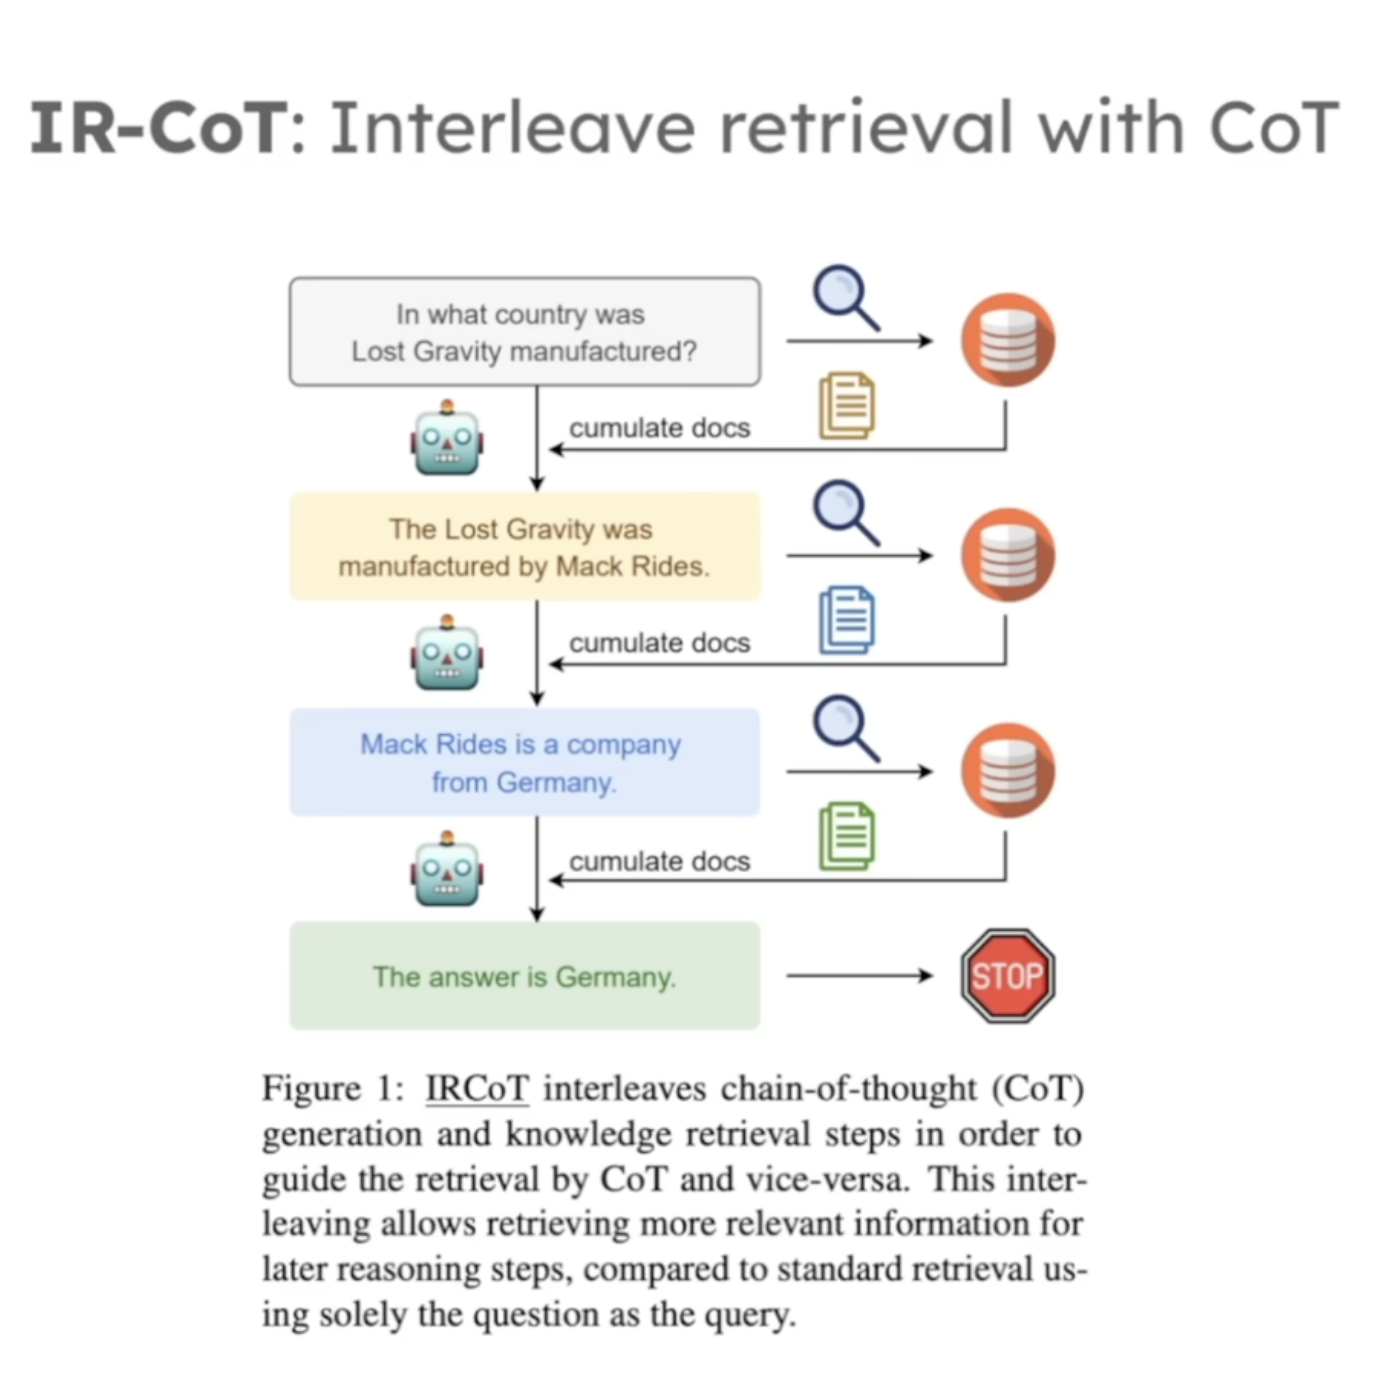

[Github link](https://github.com/langchain-ai/rag-from-scratch/blob/main/rag_from_scratch_5_to_9.ipynb)

In [3]:
from langchain.prompts import ChatPromptTemplate

# Decomposition
template = """You are a helpful assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-prblems / sub-questions that can be answers in isolateion. \n
Generate multiple search queries related to: {question} \n
Output (3 queries):"""
prompt_decomposition = ChatPromptTemplate.from_template(template)

ModuleNotFoundError: No module named 'langchain'

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# LLM
llm = ChatOpenAI(temperature=0)

# Chain
generate_queries_decomposition = ( prompt_decomposition | llm | StrOutputParser() | (lambda x: x.split("\n")))

# Run
question = "What are the main components of an LLM-powered autoomous agent system?"
questions = generate_queries_decomposition.invoke({"question":question})

**Answer recursively**

![image.png](./assets/Part7_Decomposition.png)

##### Papers
- https://arxiv.org/pdf/2205.10625.pdf
- https://arxiv.org/abs/2212.10509.pdf

In [ ]:
# Prompt
template = """Here is the question you need to answer:

\n --- \n { question } \n --- \n

Here is any available background question + answe pairs:

\n --- \n { q_a_pairs } \n --- \n

Here is additional context relevant to the question:

\n --- \n { context } \n --- \n

Use the above context and any background question + answer pairs to answer the question: \n { question }
"""

decomposition_prompt = ChatPromptTemplate.from_template(template)

In [ ]:
from operator import itemgetter
from langchain.core.output_parsers import StrOutputParser

def format_qa_pair(question, answer):
    """Fromat Q and A pair"""

    formatted_string = ""
    formatted_string += f"Question: {question}\nAnswer: {answer}\n\n"
    return formatted_string.strip()

# llm 
llm = ChatOpenAI(model_name="gpt-3.5.turbo", temperature=0)

q_a_pairs = ""
for q in question:

    rag_chain = (
    {"context": itemgetter("question") | retriever,
     "question": itemgetter("question"),
     "q_a_pairs": itemgetter("q_a_pairs")}
    | decomposition_prompt
    | llm
    | StrOutputParser())

    answer = rag_chain.invoke({"question":q,"q_a_pairs":q_a_pairs})
    q_a_pairs = format_qa_pair(q,answer)
    q_a_pairs = q_a_pairs + "\n---\n"+ q_a_pairs


#### answer

#### Trace:

Question 1:https://smith.langchain.com/public/faefde73-0ecb-4328-8fee-a237904115c0/r

Question 2:https://smith.langchain.com/public/6142cad3-b314-454e-b2c9-15146cfcce78/r

Question 3:Question 3: https://smith.langchain.com/public/84bdca0f-0fa4-46d4-9f89-a7f25bd857fe/r

**Answer individually**

![image.png](./assets/Part7_Answer_individually.png)

In [ ]:
# Anser each sub-question individually

from langchain import hub
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# RAG prompt
prompt_rag = hub.pull("rlm/rag-prompt")

def retrieve_and_rag(question,prompt_rag,sub_question_generator_chain):
    """RAG on eacg sub-question"""

    # Use our decomposition /
    sub_questions = sub_question_generator_chain.invoke({question:question})

    # Initialize a list to hold RAG chain results
    rag_results = []

    for sub_question in sub_questions:

        #Retrieve documents for each sub-question 检索每个子问题的文档
        retrieved_docs = retriever.get_relevant_documents(sub_question)

        # Use retrieved documents and sub-question in RAG chain
        answer = (prompt_rag | llm | StrOutputParser()).invoke({"context": retrieved_docs,
                                                               "question": sub_question})
        rag_results.append(answer)

    return rag_results,sub_questions

# Wrap the retrieval and RAG process in a RunnableLambda for integration into a chain 
answers, questions = retrieve_and_rag(question, prompt_rag, generate_queries_decomposition)

In [ ]:
def format_qa_pairs(questions, answers):
    """Format Q and A pairs"""

    formatted_string = ""
    for i, (question, answer) in enumerate(zip(questions, answers), start=1):
        formatted_string += f"Question {i}: {question}\nAnswer {i}: {answer}\n\n"
    return formatted_string.strip()

context = format_qa_pairs(questions, answers)

# Prompt
template = """Here is a set of Q+A pairs:

{context}

Use these to synthesize an ansser to the question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain({"context":context,"question":question})

### Part8: Step Back

![image.png](./assets/Part8_Step_back.png)

##### Papers
- https://arxiv.org/pdf/2310.06117.pdf

In [ ]:
# Few Shot Examples
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemple
examples = [
    {
        "input": "Could the members of The Police perfprm lawful arrests?",
        "output": "what can the members of The Police do?",
    },
    {
        "input": "Jan Sindel’s was born in what country?",
        "output": "what is Jan Sindel’s personal history?",
    },
]
# We now transform these toexample messages
example_prompt = ChatPromptTemplate.from_message(
    [
        ("human", "{input}"),
        ("ai","{output}"),
    ]
)
few_shot_prompt = FewShotChatMessagePromptTemple(
    example_prompt=example_prompt,
    examples=examples,
)
prompt = ChatPromptTemplate.from_message(
    [
        (
            "system",
            """You are an expert at worls knowledge. Your task is to step back and paraphrase to a more generic step-back question, which is easier to answer.Here are a few examples:"""
        ),
        # Few shot examples
        few_shot_prompt,
        # New question
        ("user", "{question}"),
    ]
)

In [ ]:
generate_queries_step_back = prompt | ChatOpenAI(temperature=0) | StrOutputParser()
question = "What is task decomposition for LLM agents?"
generate_queries_decomposition.invoke({"question": question})

In [ ]:
# Response prompt
response_prompt_template = """You are an expert of world knowledge. I am going to ask you a question. Your response should be comprehensive and not contradicted with the following context if they are relevant. Otherwise, irgore them if they are not relevant.

# {normal_context}
# {step_back_context}

# Original Question: {question}
# Answer:"""
response_prompt = ChatPromptTemplate.from_template(response_prompt_template)

chain = (
    {
        # Retireve context using the normal question
        "mormal_context": RunnableLambda(lambda x:x["question"]) | retriever,
        # Retrieve context using the step-back question
        "step_back_context": generate_queries_step_back | retriever,
        # Pass pn the question
        "question": lambda x: x["question"],
    }
    | response_prompt
    | ChatOpenAI(temperature=0)
    | StrOutputParser()
)

chain.invoke({"question": question})

### Part9: HyDE

![image.png](./assets/Part9_HyDE.png)

![image.png](./assets/Part9_Why_HyDE.png)

##### Docs

- https://github.com/langchain-ai/langchain/blob/master/cookbook/hypothetical_document_embeddings.ipynb

##### Papers

- https://arxiv.org/abs/2212.10496

In [ ]:
from langchain.prompts import ChatPromptTemplate

# HyDE decument generation 
template = """Please write a scientific paper passage to answer the question
Questuon: {question}
Passage:"""
prompt_hyde = ChatPromptTemplate.from_tempalte(template)

from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

generate_docs_for_retrieval = (
    prompt_hyde | ChatOpenAI(temperature=0) | StrOutputParser()
)

# Run
question = "What is task decomposition for LLM agents?"
generate_docs_for_retrieval.invoke({"question": question})

In [ ]:
# Retrieve
retrieval_chain = generate_docs_for_retrieval | retriever
retrieved_docs = retrieval_chain.invoke({"question":question})
retrieved_docs

In [ ]:
# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

final_rag_chain.invoke({"context":retrieved_docs,"question":question})

### **Enviorment**
#### (1) Packages

! pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain youtube-transcript-api pytube

#### (2) LangSmith
https://docs.smith.langchain.com/

import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = <your-api-key>

#### (3) API Keys

os.environ['OPENAI_API_KEY'] = <your-api-key>

### **Part10: Logical and Semantic routing**

#### Use function-calling for classification.

#### Flow:

![image.png](./assets/Part10_Logical_and_Semantic_routing.png)


#### Docs:

https://python.langchain.com/docs/use_cases/query_analysis/techniques/routing#routing-to-multiple-indexes

In [ ]:
from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_openai import ChatOpenAI

# Data model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["python_docs", "js_docs", "golang_docs"] = Field(
        ...,
        description="Given a user question choose which datasource would be most relevant for answering their question",
    )

# LLM with function call
llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)
structured_llm = llm.with_structured_output(RouteQuery)

# Prompt
system = """You are an expert at routing a user question to the appropriate data source.

Based on the programming language the question is referring to, route it to the relevant data source."""

prompt = ChatPromptTemplate.from_message(
    [
        ("system", system),
        ("hunman", "{question}"),
    ]
)

# Define router
router = prompt | structured_llm


In [ ]:
question = """Why doesn't the following code work:

from langchain_core.prompt import ChatPromptTemplate

prompt = ChatPromptTemplate.from_message([”human", "speak in {language}"])
prompt.invoke("french")
"""

result = router.invoke({"question":question})

https://python.langchain.com/docs/expression_language/how_to/routing

In [ ]:
def choose_route(result):
    if "python_docs" in result.datasource.lower():
        ### Logic here
        return "chain for python_docs"
    elif "js_docs" in result.datasource.lower():
        ### Logic here
        return "chain for js_docs"
    else:
        ### Logic here
        return "chain for golang_docs"
    
from langchain_core.runnables import RunnableLambda

full_chain = router | RunnableLambda(choose_route)

#### Trace:

https://smith.langchain.com/public/c2ca61b4-3810-45d0-a156-3d6a73e9ee2a/r

#### **Semantic routing**

##### Flow:

![image.png](./assets/Part10_Semantic_routing.png)


#### Docs:

https://python.langchain.com/docs/expression_language/cookbook/embedding_router

In [ ]:
from langchain.utils.math import cosine_similarity
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Two prompts
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise and easy to understand manner. \
When you don't know the answer to a question you admit that you don't know.

Here is a question:
{query}"""

math_template = """You are avery good mathematician. You are grear at answering math questions. \
You are so good because you are able to break down hard problems into their component parts, \
answer the component parts, and then put them together to answer the broader question.

Here is a question:
{query}"""

# Embed prompts
embeddings = OpenAIEmbeddings()
prompt_templates = [physics_template, math_template]
prompt_embeddings = embeddings.embed_documents(prompt_templates)

# Route question to prompt
def prompt_router(input):
    # Embed question
    query_embedding = embeddings.embed_query(input["query"])
    # Computer similarity
    similarity = cosine_similarity([query_embedding], prompt_embeddings)[0]
    most_similar = prompt_templates[similarity.argmax()]
    # Chosen prompt
    print("Using MATH" if most_similar == math_template else "Using PHYSICS")
    return PromptTemplate.from_template(most_similar)

chain = {
    {"query": RunnablePassthrough()}
    | RunnableLambda(prompt_router)
    | ChatOpenAI()
    | StrOutputParser()
}

print(chain.invoke("What's a black hole"))

## Rag From Scratch: Query Construction

![image.png](./assets/Part10_Query_Construction.png)

#### For graph and SQL, see helpful resources:
- https://blog.langchain.dev/query-construction/
- https://blog.langchain.dev/enhancing-rag-based-applications-accuracy-by-constructing-and-leveraging-knowledge-graphs/

### **Part 11: Query structuring for metadata filters**

#### Flow:

![image.png](./assets/Part11_Query_structuring_for_metadata_filters.png)


#### Many vectorstores contain metadata fields.

#### This makes it possible to filter for specific chunks based on metadata.

#### Let's look at some example metadata we might see in a database of YouTube transcripts.

#### Docs:

- https://python.langchain.com/docs/use_cases/query_analysis/techniques/structuring

In [ ]:
from langchain_community.document_loaders import YoutubeLoader

docs =  YoutubeLoader.from_youtube_url(
    "https://www.youtube.com/watch?v=pbAd801Lvm4", add_video_info=True
).load()

docs[0].metadata

##### Let’s assume we’ve built an index that:

##### Allows us to perform unstructured search over the contents and title of each document
##### And to use range filtering on view count, publication date, and length.
##### We want to convert natural language into structured search queries.

##### We can define a schema for structured search queries.

In [ ]:
import datatime
from typing import Literal, Optional, Tuple
from langchain_core.pydantic_v1 import BaseModel, Field

class TutorialSearch(BaseModel):
    """Search over adatabase of tutorial videos about a software library."""

    content_search: str = Field(
        ...,
        description="Similarity search query applied to video transcripts",
    )
    title_search: str = Field(
        ...,
        description=(
            "Alternate version of the content search query to apply to video titles."
            "Should be succinct and only include key words that could be in a video."
            "titlw"
        ),
    )
    min_view_count: Optional[int] = Field(
        None,
        description="Minimum view count filter, inclusive. Only usr id explicitly specified.",
    )
    max_view_count: Optional[int] = Field(
        None,
        description="Maximum view count filter, exclusive. Only use if explicitly specified.",
    )
    earliest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Earliest publish date filter, inclusive. Only use if explicitly specified.",
    )
    latest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Latest publish date filter, exclusive. Only use if explicitly specified.",
    )
    min_length_sec: Optional[int] = Field(
        None,
        description="Minimum video length in seconds, inclusive. Only use if explicitly specified.",
    )
    max_length_sec: Optional[int] = Field(
        None,
        description="Maximum video length in seconds, exclusive. Only use if explicitly specified.",
    )

    def pretty_print(self) -> None:
        for field in self.__fields__:
            if getattr(self, field) is not None and getattr(self, field) != getattr(
                self.__fields__[field], "default", None
            ):
                print(f"{field}: {getattr(self, field)}")

##### Now, we prompt the LLM to produce queries.